# Faust: Real-Time Tweet Sentiment Analysis

This notebook demonstrates a complete real-time sentiment analysis pipeline built with Faust.

**Pipeline overview:**
```
CSV dataset → tweet_producer.py → Kafka ("tweets")
                                         ↓
                                   faust_app.py (Faust worker)
                                         ↓
                                  Kafka ("sentiment_results")
                                         ↓
                                   dashboard.py (Streamlit)
```

The notebook covers five parts:
1. Load and explore the Sentiment140 tweet dataset
2. Run sentiment analysis directly on a sample batch
3. Evaluate model accuracy against ground-truth labels
4. Visualize the sentiment distribution
5. Read live results from Kafka (requires the pipeline to be running)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

import faust_utils as fauuti

logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Load and Explore the Dataset

The Sentiment140 dataset contains 1.6 million tweets labeled with:
- `0` → negative
- `2` → neutral
- `4` → positive

We load a small sample for exploration.

In [3]:
CSV_PATH = "training.1600000.processed.noemoticon.csv"
# Load 50 tweets for this notebook.
tweets = fauuti.load_tweets(CSV_PATH, limit=50)
df_raw = fauuti.tweets_to_dataframe(tweets)
print(f"Loaded {len(df_raw)} tweets")
df_raw.head(10)

INFO:faust_utils:Loading up to 50 tweets from training.1600000.processed.noemoticon.csv
INFO:faust_utils:Loaded 50 tweets


Loaded 50 tweets


,sentiment,id,date,user,text
0,negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
2,negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
3,negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
4,negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."
5,negative,1467811372,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,@Kwesidei not the whole crew
6,negative,1467811592,Mon Apr 06 22:20:03 PDT 2009,mybirch,Need a hug
7,negative,1467811594,Mon Apr 06 22:20:03 PDT 2009,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,negative,1467811795,Mon Apr 06 22:20:05 PDT 2009,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,negative,1467812025,Mon Apr 06 22:20:09 PDT 2009,mimismo,@twittera que me muera ?


In [4]:
# Show the distribution of ground-truth sentiment labels.
print("Ground-truth label counts:")
print(df_raw["sentiment"].value_counts())

Ground-truth label counts:
sentiment
negative    50
Name: count, dtype: int64


In [5]:
# Preview the text of the first few tweets.
for i, row in df_raw.head(5).iterrows():
    print(f"[{row['sentiment']:8s}] {row['text'][:80]}")

[negative] @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got D
[negative] is upset that he can't update his Facebook by texting it... and might cry as a r
[negative] @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out 
[negative] my whole body feels itchy and like its on fire 
[negative] @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I


## Part 2: Run Sentiment Analysis on a Sample Batch

We load the HuggingFace model and classify 20 tweets directly.
This demonstrates the core analysis logic without needing Kafka running.

The model (`cardiffnlp/twitter-roberta-base-sentiment-latest`) was trained
specifically on Twitter data, making it well-suited for this task.
It outputs one of three labels: `negative`, `neutral`, `positive`.

In [6]:
# Load the Twitter-specific sentiment model (cached after first download).
classifier = fauuti.load_sentiment_model()

INFO:faust_utils:Loading sentiment model: cardiffnlp/twitter-roberta-base-sentiment-latest
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [7]:
# Run sentiment analysis on the first 20 tweets.
sample_tweets = tweets[:20]
df_results = fauuti.analyze_tweets_batch(sample_tweets, classifier)
df_results

/pytorch/third_party/ideep/mkl-dnn/src/cpu/aarch64/xbyak_aarch64/src/util_impl_linux.h, 451: Can't read MIDR_EL1 sysfs entry


,text,original_sentiment,predicted_sentiment,confidence
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",negative,negative,0.7458
1,is upset that he can't update his Facebook by ...,negative,negative,0.9005
2,@Kenichan I dived many times for the ball. Man...,negative,neutral,0.6560
3,my whole body feels itchy and like its on fire,negative,negative,0.8976
4,"@nationwideclass no, it's not behaving at all....",negative,negative,0.9312
5,@Kwesidei not the whole crew,negative,neutral,0.6053
6,Need a hug,negative,neutral,0.6587
7,@LOLTrish hey long time no see! Yes.. Rains a...,negative,positive,0.9222
8,@Tatiana_K nope they didn't have it,negative,neutral,0.5189
9,@twittera que me muera ?,negative,neutral,0.8835


In [8]:
# Show a side-by-side comparison of original vs predicted labels.
comparison = df_results[["text", "original_sentiment", "predicted_sentiment", "confidence"]].copy()
comparison["text"] = comparison["text"].str[:60]
print(comparison.to_string(index=False))

                                                        text original_sentiment predicted_sentiment  confidence
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer           negative            negative      0.7458
is upset that he can't update his Facebook by texting it...            negative            negative      0.9005
@Kenichan I dived many times for the ball. Managed to save 5           negative             neutral      0.6560
             my whole body feels itchy and like its on fire            negative            negative      0.8976
@nationwideclass no, it's not behaving at all. i'm mad. why            negative            negative      0.9312
                               @Kwesidei not the whole crew            negative             neutral      0.6053
                                                 Need a hug            negative             neutral      0.6587
@LOLTrish hey  long time no see! Yes.. Rains a bit ,only a b           negative            positive     

## Part 3: Evaluate Model Accuracy

Compare the model's predicted sentiment against the Sentiment140 ground-truth labels.

Note: the original labels are binary (negative/positive), while the model also
predicts neutral — so some disagreement is expected.

In [9]:
# Compute overall accuracy on the sample.
acc = fauuti.accuracy_score(df_results)
correct = int(acc * len(df_results))
print(f"Accuracy: {acc:.1%}  ({correct}/{len(df_results)} correct)")

Accuracy: 45.0%  (9/20 correct)


In [10]:
# Show only the tweets where the model disagreed with the original label.
mismatches = df_results[
    df_results["original_sentiment"] != df_results["predicted_sentiment"]
].copy()
mismatches["text"] = mismatches["text"].str[:60]
print(f"Mismatches: {len(mismatches)}")
mismatches[["text", "original_sentiment", "predicted_sentiment", "confidence"]]

Mismatches: 11


,text,original_sentiment,predicted_sentiment,confidence
2,@Kenichan I dived many times for the ball. Man...,negative,neutral,0.6560
5,@Kwesidei not the whole crew,negative,neutral,0.6053
6,Need a hug,negative,neutral,0.6587
7,@LOLTrish hey long time no see! Yes.. Rains a...,negative,positive,0.9222
8,@Tatiana_K nope they didn't have it,negative,neutral,0.5189
9,@twittera que me muera ?,negative,neutral,0.8835
10,spring break in plain city... it's snowing,negative,neutral,0.6654
11,I just re-pierced my ears,negative,neutral,0.7557
15,@iamjazzyfizzle I wish I got to watch it with ...,negative,positive,0.8470
17,about to file taxes,negative,neutral,0.8760


## Part 4: Visualize Results

Plot the sentiment distribution and confidence scores from the model's predictions.

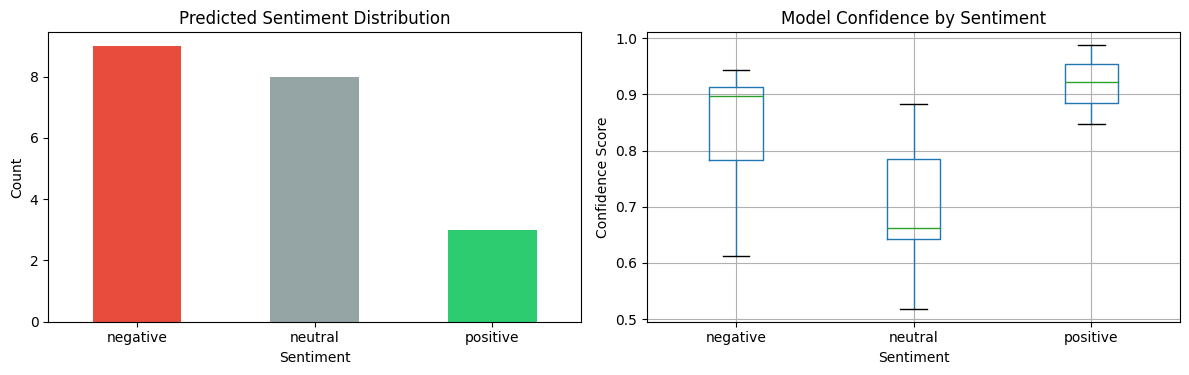

In [11]:
counts = fauuti.sentiment_summary(df_results)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of sentiment label counts.
colors = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
bar_colors = [colors.get(label, "#3498db") for label in counts.index]
counts.plot(kind="bar", ax=axes[0], color=bar_colors)
axes[0].set_title("Predicted Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Box plot of confidence scores grouped by predicted sentiment.
df_results.boxplot(column="confidence", by="predicted_sentiment", ax=axes[1])
axes[1].set_title("Model Confidence by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Confidence Score")

plt.suptitle("")
plt.tight_layout()
plt.show()

## Part 5: Read Live Results from Kafka

If the full pipeline is running (Kafka + Faust worker + tweet producer),
this cell reads from the `sentiment_results` Kafka topic and displays a
live snapshot of processed tweets.

To start the pipeline, run in separate terminals:
```bash
# Terminal 1
docker compose up -d

# Terminal 2
python3 -m faust -A faust_app worker -l info

# Terminal 3
python3 tweet_producer.py
```

In [17]:
import socket
socket.gethostbyname('host.docker.internal')

'192.168.65.254'

In [16]:
try:
    consumer = fauuti.create_kafka_consumer(
        topic="sentiment_results",
        timeout_ms=5000,
    )
    df_live = fauuti.poll_sentiment_results(consumer, max_messages=200)
    if df_live.empty:
        print("No results found. Start the pipeline first (see instructions above).")
    else:
        print(f"Read {len(df_live)} results from Kafka")
        print("\nSentiment counts:")
        print(fauuti.sentiment_summary(df_live))
        df_live["text"] = df_live["text"].str[:60]
        display(df_live.head(10))
except Exception as e:
    print(f"Could not connect to Kafka: {e}")
    print("Start the pipeline first using the terminal commands above.")

INFO:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: connecting to localhost:9092 [('::1', 9092, 0, 0) IPv6]
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connect attempt returned error 111. Disconnecting.
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Closing connection. KafkaConnectionError: 111 ECONNREFUSED
INFO:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv4 ('127.0.0.1', 9092)]>: connecting to localhost:9092 [('127.0.0.1', 9092) IPv4]
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv4 ('127.0.0.1', 9092)]>: Connect attempt returned error 111. Disconnec

Could not connect to Kafka: NoBrokersAvailable
Start the pipeline first using the terminal commands above.
